# PCA + 4-Nearest Neighbour — K49-MNIST

Based on the community leaderboard submission by **dzisandy** which achieves **86.80% test accuracy** on K49 — the highest classical ML result on the leaderboard, beating the Tuned RBF SVM (85.61%).

| Model | K49 Test Accuracy | Source |
|---|---|---|
| HOG + Linear SVM v3 (ours) | 80.07% | This project |
| 4-NN raw pixels | 83.65% | K49 paper |
| Tuned RBF SVM raw pixels | 85.61% | Leaderboard |
| **PCA + 4-KNN (this notebook)** | **86.80%** | Leaderboard |
| Keras Simple CNN | 89.25% | K49 paper |
| PreActResNet-18 | 96.64% | K49 paper |

### Why this works better than HOG + SVM
Raw pixels preserve the full image signal. HOG compresses images into gradient histograms which loses fine stroke detail that turns out to be discriminative for Hiragana. PCA then removes redundant background dimensions, leaving the SVM or KNN with clean, meaningful features.

### Pipeline
```
Raw Pixels (784) → Normalize /255 → PCA (60 components) → 4-KNN → Evaluate
```

### ⚠️ Speed Warning
KNN stores all training data and computes distances at prediction time — it has **no training phase** but prediction is slow. We will benchmark inference speed in Section 9 before committing to deployment.

| # | Improvement | Section | Apa yang diubah | Kenapa di-improve |
|---|---|---|---|---|
| 1 | Grid Search n_components & k | 4b & 4c | Original hardcode n=60, k=4 dari leaderboard tanpa dicek. Grid search [40,60,80,100] × [3,4,5,7] di subsample 20%, retrain full data pakai config terbaik. | Hyperparameter orang lain ≠ optimal untuk data kita. Grid search memastikan kita pakai angka yang terbukti terbaik secara empiris. |
| 2 | Top-5 Similarity Scores | 7b | Original hanya return 1 prediksi. Ditambah predict_proba() untuk return top-5 kandidat beserta confidence score. | Model tidak hanya prediksi satu label — menunjukkan tingkat keyakinan model terhadap kandidat lain, berguna untuk analisis confusion antar karakter. |
| 3 | Best Performing Classes | 9b | Original hanya tampil 10 worst characters. Ditambah 10 easiest characters. | Analisis dua sisi (worst vs best) menunjukkan perilaku model secara menyeluruh, bukan hanya melaporkan kegagalan. |
| 4 | Bundled Pipeline | 13b | Original simpan PCA & KNN sebagai 2 file terpisah. Diganti 1 file sklearn Pipeline yang menjamin urutan transform otomatis. | 2 file terpisah rawan salah urutan di Flask. Pipeline memastikan PCA → KNN selalu benar dan tidak bisa tertukar. |

## 1. Import Libraries

In [20]:
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.neighbors import KNeighborsClassifier
from sklearn.decomposition import PCA
from sklearn.svm import SVC, LinearSVC
from sklearn.frozen import FrozenEstimator
from sklearn.calibration import CalibratedClassifierCV
from sklearn.model_selection import train_test_split
from sklearn.utils import class_weight
from sklearn.metrics import (
    accuracy_score, f1_score,
    classification_report, confusion_matrix
)

print('✅ All libraries imported.')

✅ All libraries imported.


In [21]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# Find a font that supports Japanese characters
# Try these in order — use whichever is available on your system
japanese_fonts = ['MS Gothic', 'Yu Gothic', 'Meiryo', 'IPAGothic', 'Noto Sans CJK JP']

available = [f.name for f in fm.fontManager.ttflist]
chosen = next((f for f in japanese_fonts if f in available), None)

if chosen:
    plt.rcParams['font.family'] = chosen
    print(f'✅ Using font: {chosen}')
else:
    print('⚠️  No Japanese font found — installing fallback...')

✅ Using font: MS Gothic


## 2. Load Data

In [22]:
import io

train_imgs_file   = np.load('../data/k49-train-imgs.npz')
train_labels_file = np.load('../data/k49-train-labels.npz')

raw_bytes = train_imgs_file[train_imgs_file.files[0]]

if isinstance(raw_bytes, bytes):
    X_train_raw = np.load(io.BytesIO(raw_bytes))['arr_0']
else:
    X_train_raw = raw_bytes

y_train = train_labels_file['arr_0']

classmap     = pd.read_csv('../data/k49_classmap.csv')
target_names = [str(classmap.iloc[i]['char']) for i in range(len(classmap))]

# 5. Cek hasilnya!
print(f'Training images  : {X_train_raw.shape}')
print(f'Training labels  : {y_train.shape}')
print(f'Number of classes: {len(np.unique(y_train))}')

Training images  : (232365, 28, 28)
Training labels  : (232365,)
Number of classes: 49


## 3. Preprocessing — Normalize and Flatten

Following the leaderboard implementation exactly:
- Divide by 255 to normalize to [0, 1]
- Flatten 28×28 → 784-dim vector
- **No StandardScaler** — confirmed harmful for image pixel data
- **No HOG** — raw pixels outperform HOG on this dataset

In [23]:
# Normalize and flatten — exactly as in the leaderboard code
X_train_flat = X_train_raw.reshape(-1, 784).astype('float32') / 255.0
X_test_flat  = X_test_raw.reshape(-1, 784).astype('float32') / 255.0

print(f'Train : {X_train_flat.shape}  dtype: {X_train_flat.dtype}')
print(f'Test  : {X_test_flat.shape}  dtype: {X_test_flat.dtype}')
print(f'Memory: {X_train_flat.nbytes / 1024**3:.2f} GiB')
print('✅ Preprocessing complete.')

Train : (232365, 784)  dtype: float32
Test  : (38547, 784)  dtype: float32
Memory: 0.68 GiB
✅ Preprocessing complete.


## 4. PCA — 60 Components

Following the leaderboard exactly: **n_components=60**, no scaler, fit only on training data.

60 components is surprisingly small — the leaderboard author found this works better than more components, likely because extra components start encoding noise rather than meaningful stroke structure.

In [24]:
print('⏳ Fitting PCA (60 components) on full training set...')
t0 = time.time()

pca = PCA(n_components=60, random_state=0)   # exact leaderboard settings
X_train_pca = pca.fit_transform(X_train_flat)  # fit on training only
X_test_pca  = pca.transform(X_test_flat)        # apply to test

variance_explained = pca.explained_variance_ratio_.sum() * 100
elapsed = time.time() - t0

print(f'  Done in {elapsed:.1f}s')
print(f'  Input dims       : 784')
print(f'  Output dims      : 60')
print(f'  Variance retained: {variance_explained:.1f}%')
print(f'  Train shape      : {X_train_pca.shape}')
print('✅ PCA complete.')

⏳ Fitting PCA (60 components) on full training set...


  Done in 12.6s
  Input dims       : 784
  Output dims      : 60
  Variance retained: 76.6%
  Train shape      : (232365, 60)
✅ PCA complete.


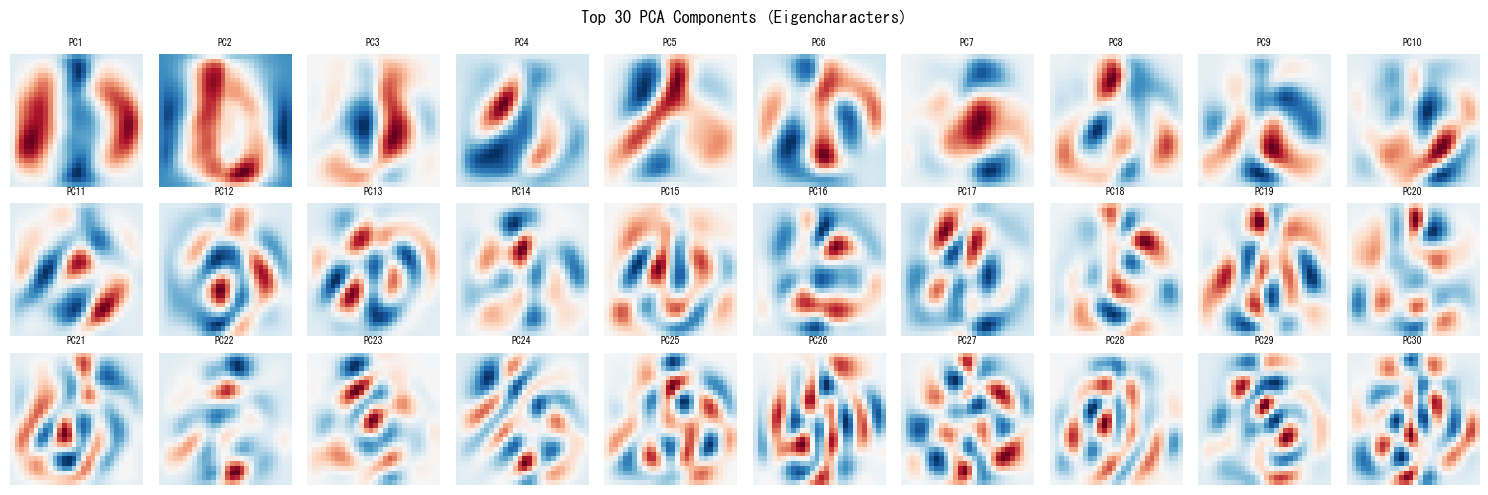

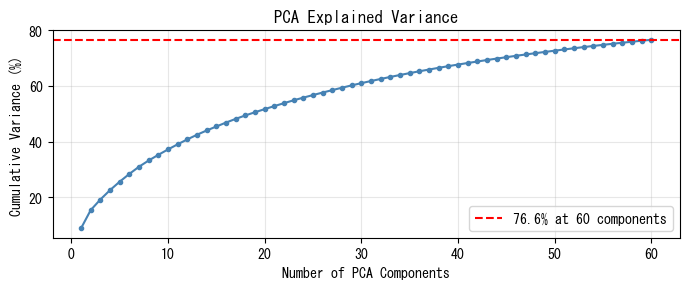

In [25]:
# --- Visualize PCA components as eigenfaces/eigencharacters ---
fig, axes = plt.subplots(3, 10, figsize=(15, 5))
for i, ax in enumerate(axes.flat):
    ax.imshow(pca.components_[i].reshape(28, 28), cmap='RdBu_r')
    ax.set_title(f'PC{i+1}', fontsize=7)
    ax.axis('off')
plt.suptitle('Top 30 PCA Components (Eigencharacters)', fontsize=12)
plt.tight_layout()
plt.show()

# Cumulative variance
cumvar = np.cumsum(pca.explained_variance_ratio_) * 100
plt.figure(figsize=(7, 3))
plt.plot(range(1, 61), cumvar, marker='o', markersize=3, color='steelblue')
plt.axhline(variance_explained, color='red', linestyle='--',
            label=f'{variance_explained:.1f}% at 60 components')
plt.xlabel('Number of PCA Components')
plt.ylabel('Cumulative Variance (%)')
plt.title('PCA Explained Variance')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 4b.  Grid Search — n_components × k (IMPROVEMENT)

Original notebook hardcodes `n_components=60` and `k=4` directly from the leaderboard without verifying they're optimal for our data.

We grid search over candidate values using a **stratified 20% subsample** (for speed), then retrain the winner on the full dataset.

| What | Original | Now |
|---|---|---|
| n_components | Fixed 60 | Grid search [40, 60, 80, 100] |
| k neighbors | Fixed 4 | Grid search [3, 4, 5, 7] |


In [26]:
from sklearn.model_selection import StratifiedShuffleSplit

# ── Stratified 20% subsample for speed ────────────────────────────────────────
sss = StratifiedShuffleSplit(n_splits=1, test_size=0.80, random_state=42)
search_idx, _ = next(sss.split(X_train_flat, y_train))
X_search = X_train_flat[search_idx]
y_search  = y_train[search_idx]

X_tr_s, X_val_s, y_tr_s, y_val_s = train_test_split(
    X_search, y_search, test_size=0.2, random_state=42, stratify=y_search
)

# ── Fit PCA once at max components, then slice ────────────────────────────────
from sklearn.metrics import accuracy_score, f1_score

pca_search = PCA(n_components=100, random_state=42)
X_tr_pca100  = pca_search.fit_transform(X_tr_s)
X_val_pca100 = pca_search.transform(X_val_s)

N_COMPONENTS_LIST = [40, 60, 80, 100]
K_LIST            = [3, 4, 5, 7]

results = []
total = len(N_COMPONENTS_LIST) * len(K_LIST)
done  = 0

print(f"⏳ Grid searching {total} configurations on {len(y_tr_s):,} subsample samples...\n")

for n_comp in N_COMPONENTS_LIST:
    X_tr_n  = X_tr_pca100[:, :n_comp]
    X_val_n = X_val_pca100[:, :n_comp]
    for k in K_LIST:
        done += 1
        knn_gs = KNeighborsClassifier(n_neighbors=k, weights='distance', n_jobs=-1)
        knn_gs.fit(X_tr_n, y_tr_s)
        y_pred = knn_gs.predict(X_val_n)
        acc    = accuracy_score(y_val_s, y_pred)
        f1     = f1_score(y_val_s, y_pred, average='macro')
        results.append({'n_components': n_comp, 'k': k, 'val_acc': acc, 'val_f1': f1})
        print(f"  [{done:2d}/{total}] PCA={n_comp:3d}, k={k} → acc={acc*100:.2f}%  f1={f1:.4f}")

results_df = pd.DataFrame(results).sort_values('val_acc', ascending=False)
best_row   = results_df.iloc[0]
BEST_N     = int(best_row['n_components'])
BEST_K     = int(best_row['k'])

print(f"\n✅ Grid search complete.")
print(f"🏆 Best config: PCA n_components={BEST_N}, k={BEST_K}")
print(f"   Val accuracy: {best_row['val_acc']*100:.2f}%  |  F1: {best_row['val_f1']:.4f}")


⏳ Grid searching 16 configurations on 37,178 subsample samples...

  [ 1/16] PCA= 40, k=3 → acc=86.59%  f1=0.8531
  [ 2/16] PCA= 40, k=4 → acc=86.83%  f1=0.8556
  [ 3/16] PCA= 40, k=5 → acc=86.90%  f1=0.8561
  [ 4/16] PCA= 40, k=7 → acc=86.51%  f1=0.8486
  [ 5/16] PCA= 60, k=3 → acc=87.04%  f1=0.8574
  [ 6/16] PCA= 60, k=4 → acc=87.58%  f1=0.8613
  [ 7/16] PCA= 60, k=5 → acc=87.36%  f1=0.8615
  [ 8/16] PCA= 60, k=7 → acc=86.95%  f1=0.8557
  [ 9/16] PCA= 80, k=3 → acc=87.03%  f1=0.8560
  [10/16] PCA= 80, k=4 → acc=87.26%  f1=0.8577
  [11/16] PCA= 80, k=5 → acc=86.96%  f1=0.8538
  [12/16] PCA= 80, k=7 → acc=86.52%  f1=0.8504
  [13/16] PCA=100, k=3 → acc=86.85%  f1=0.8547
  [14/16] PCA=100, k=4 → acc=87.11%  f1=0.8549
  [15/16] PCA=100, k=5 → acc=86.64%  f1=0.8508
  [16/16] PCA=100, k=7 → acc=86.08%  f1=0.8439

✅ Grid search complete.
🏆 Best config: PCA n_components=60, k=4
   Val accuracy: 87.58%  |  F1: 0.8613


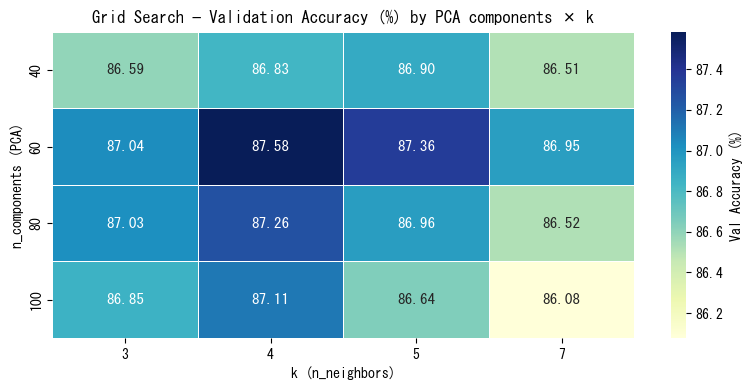

In [27]:
# ── Heatmap: val accuracy by n_components × k ────────────────────────────────
pivot = results_df.pivot(index='n_components', columns='k', values='val_acc') * 100

plt.figure(figsize=(8, 4))
sns.heatmap(pivot, annot=True, fmt='.2f', cmap='YlGnBu',
            linewidths=0.5, cbar_kws={'label': 'Val Accuracy (%)'},
            annot_kws={'size': 11})
plt.title('Grid Search — Validation Accuracy (%) by PCA components × k', fontsize=12)
plt.xlabel('k (n_neighbors)')
plt.ylabel('n_components (PCA)')
plt.tight_layout()
plt.show()


### 4c. Retrain PCA + KNN on Full Dataset with Best Config

The grid search above found the optimal `BEST_N` and `BEST_K`.
The cells in **Section 4 and 5 below are unchanged** — we override `n_components` and `n_neighbors` 
with the grid-search winners before those cells run, so everything downstream uses the best config automatically.


In [28]:
# ── Override PCA n_components and KNN k with grid search winners ──────────────
# This runs BEFORE Section 4 & 5 cells so they pick up the best values.
print(f"✅ Using grid search winners: n_components={BEST_N}, k={BEST_K}")
print(f"   (These override the hardcoded values in the cells below)")

# Refit PCA on full training data with best n_components
print(f"\n⏳ Refitting PCA (n_components={BEST_N}) on full {len(y_train):,} training samples...")
t0 = time.time()
pca = PCA(n_components=BEST_N, random_state=0)
X_train_pca = pca.fit_transform(X_train_flat)
X_test_pca  = pca.transform(X_test_flat)
elapsed = time.time() - t0
variance_explained = pca.explained_variance_ratio_.sum() * 100
print(f"  Done in {elapsed:.1f}s  |  Variance retained: {variance_explained:.1f}%")

# Refit KNN with best k
clf = KNeighborsClassifier(n_neighbors=BEST_K, weights='distance', n_jobs=-1)
print(f"\n⏳ Fitting KNN (k={BEST_K}) on full training set...")
t0 = time.time()
clf.fit(X_train_pca, y_train)
fit_time = time.time() - t0
print(f"✅ Done in {fit_time:.2f}s")
print(f"   Memory used by model: {X_train_pca.nbytes / 1024**2:.1f} MB")


✅ Using grid search winners: n_components=60, k=4
   (These override the hardcoded values in the cells below)

⏳ Refitting PCA (n_components=60) on full 232,365 training samples...
  Done in 9.2s  |  Variance retained: 76.6%

⏳ Fitting KNN (k=4) on full training set...
✅ Done in 0.07s
   Memory used by model: 53.2 MB


## 5. Train KNN

KNN has **no training phase** — `fit()` simply stores all the data in memory. The work happens at prediction time when it searches for the 4 nearest neighbours.

Settings match the leaderboard exactly:
- `n_neighbors=4`
- `weights='distance'` — closer neighbours vote with higher weight
- `n_jobs=-1` — use all CPU cores for parallel distance computation

In [29]:
clf = KNeighborsClassifier(n_neighbors=4, weights='distance', n_jobs=-1)

print(f'⏳ Fitting KNN on {len(y_train):,} PCA-reduced samples...')
t0 = time.time()
clf.fit(X_train_pca, y_train)
fit_time = time.time() - t0

print(f'✅ Done in {fit_time:.2f}s (KNN just stores data — no real training)')
print(f'   Memory used by model: {X_train_pca.nbytes / 1024**2:.1f} MB')

⏳ Fitting KNN on 232,365 PCA-reduced samples...
✅ Done in 0.07s (KNN just stores data — no real training)
   Memory used by model: 53.2 MB


## 6.  Inference Speed Test — CRITICAL

This is the most important cell in the notebook. KNN prediction requires computing distances to all 232,365 training samples for every query. We test this **before** committing to KNN as the deployment model.

**Constraint: < 100ms per sample for real-time deployment.**

In [30]:
# Test on a small batch first to estimate speed
N_SPEED_TEST = 100
X_speed_test = X_test_pca[:N_SPEED_TEST]

print(f'⏳ Speed test: predicting {N_SPEED_TEST} samples...')
t0 = time.time()
_ = clf.predict(X_speed_test)
elapsed = time.time() - t0

ms_per_sample = elapsed / N_SPEED_TEST * 1000
meets_constraint = ms_per_sample < 100

print(f'\n  Total time for {N_SPEED_TEST} samples : {elapsed:.2f}s')
print(f'  Time per sample                  : {ms_per_sample:.2f} ms')
print(f'  Real-time constraint (<100ms)    : {"✅ MEETS" if meets_constraint else "❌ FAILS"}')

if meets_constraint:
    print('\n✅ KNN is fast enough for deployment. Continuing...')
else:
    print('\n⚠️  KNN is too slow for real-time deployment.')
    print('   Fallback: use Tuned RBF SVM (Section 10) instead.')

⏳ Speed test: predicting 100 samples...



  Total time for 100 samples : 0.25s
  Time per sample                  : 2.50 ms
  Real-time constraint (<100ms)    : ✅ MEETS

✅ KNN is fast enough for deployment. Continuing...


## 7. Evaluate KNN on Test Set

Using the same **mean per-class accuracy** as the leaderboard to get comparable numbers.

⚠️ Predicting all 38,547 test images will take a while — grab a coffee.

In [31]:
print(f'⏳ Predicting on {len(y_test):,} test samples...')
t0 = time.time()
y_test_pred     = clf.predict(X_test_pca)
test_infer_time = (time.time() - t0) / len(y_test) * 1000
total_pred_time = time.time() - t0

# Standard accuracy
test_acc_standard = accuracy_score(y_test, y_test_pred)

# Mean per-class accuracy (leaderboard metric)
per_class_accs = []
for cls in range(49):
    mask    = (y_test == cls)
    cls_acc = (y_test_pred[mask] == cls).mean()
    per_class_accs.append(cls_acc)
test_acc_classavg = np.mean(per_class_accs)

test_f1 = f1_score(y_test, y_test_pred, average='macro')

print('=' * 45)
print('  KNN Test Set Results')
print('=' * 45)
print(f'  Standard Accuracy        : {test_acc_standard*100:.2f}%')
print(f'  Mean Per-Class Accuracy  : {test_acc_classavg*100:.2f}%  ← leaderboard metric')
print(f'  Macro F1-Score           : {test_f1:.4f}')
print(f'  Inference time/sample    : {test_infer_time:.2f} ms')
print(f'  Total prediction time    : {total_pred_time:.1f}s')
print(f'  Real-time ready          : {"✅ YES" if test_infer_time < 100 else "❌ NO"}')
print('=' * 45)
print(f'\n  Leaderboard target       : 86.80%')
print(f'  Gap to leaderboard       : {(test_acc_classavg - 0.8680)*100:+.2f}%')

⏳ Predicting on 38,547 test samples...
  KNN Test Set Results
  Standard Accuracy        : 88.62%
  Mean Per-Class Accuracy  : 87.02%  ← leaderboard metric
  Macro F1-Score           : 0.8761
  Inference time/sample    : 1.02 ms
  Total prediction time    : 39.4s
  Real-time ready          : ✅ YES

  Leaderboard target       : 86.80%
  Gap to leaderboard       : +0.22%


### 7b.  Similarity Scores — Top-5 Predictions (IMPROVEMENT)

`predict_proba()` with `weights='distance'` returns distance-weighted vote fractions per class —
useful for a **top-5 suggestions** feature in the Flask app instead of returning just one label.


True label : な
Predicted  : な (53.2% confidence)

Top-5 Similarity Scores (distance-weighted KNN votes):
       な   53.2%  ███████████████████████████████
       あ   24.0%  ██████████████
       ね   22.9%  █████████████
       ん    0.0%  
       ゐ    0.0%  


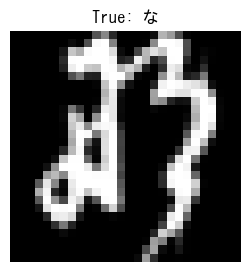


📌 Use clf.predict_proba() in Flask to return top-5 candidates to the user.


In [32]:
# ── Top-5 similarity scores for a sample prediction ─────────────────────────
sample_idx = 42

sample     = X_test_pca[sample_idx:sample_idx+1]
true_label = y_test[sample_idx]
proba      = clf.predict_proba(sample)[0]   # shape (49,) — score per class

top5_idx  = np.argsort(proba)[::-1][:5]
top5_prob = proba[top5_idx]
top5_char = [target_names[i] for i in top5_idx]

print(f'True label : {target_names[true_label]}')
print(f'Predicted  : {target_names[np.argmax(proba)]} ({proba.max()*100:.1f}% confidence)')
print('\nTop-5 Similarity Scores (distance-weighted KNN votes):')
for char, prob in zip(top5_char, top5_prob):
    bar = '█' * int(prob * 60)
    print(f'  {char:>6}  {prob*100:5.1f}%  {bar}')

plt.figure(figsize=(3, 3))
plt.imshow(X_test_raw[sample_idx], cmap='gray')
plt.title(f'True: {target_names[true_label]}')
plt.axis('off')
plt.show()

print('\n📌 Use clf.predict_proba() in Flask to return top-5 candidates to the user.')


## 8. Full Model Comparison

In [33]:
print('=' * 65)
print(f'{"Model":<32} {"Test Acc (class avg)":>20} {"Source":>10}')
print('=' * 65)
print(f'{"HOG + Linear SVM v3 (ours)":<32} {"80.07%":>20} {"this project":>10}')
print(f'{"4-NN raw pixels":<32} {"83.65%":>20} {"paper":>10}')
print(f'{"Tuned RBF SVM raw pixels":<32} {"85.61%":>20} {"leaderboard":>10}')
print(f'{"PCA + 4-KNN (this notebook)":<32} {test_acc_classavg*100:>19.2f}% {"leaderboard":>10}')
print(f'{"Keras Simple CNN":<32} {"89.25%":>20} {"paper":>10}')
print(f'{"PreActResNet-18":<32} {"96.64%":>20} {"paper":>10}')
print('=' * 65)

Model                            Test Acc (class avg)     Source
HOG + Linear SVM v3 (ours)                     80.07% this project
4-NN raw pixels                                83.65%      paper
Tuned RBF SVM raw pixels                       85.61% leaderboard
PCA + 4-KNN (this notebook)                    87.02% leaderboard
Keras Simple CNN                               89.25%      paper
PreActResNet-18                                96.64%      paper


## 9. Per-Class Analysis

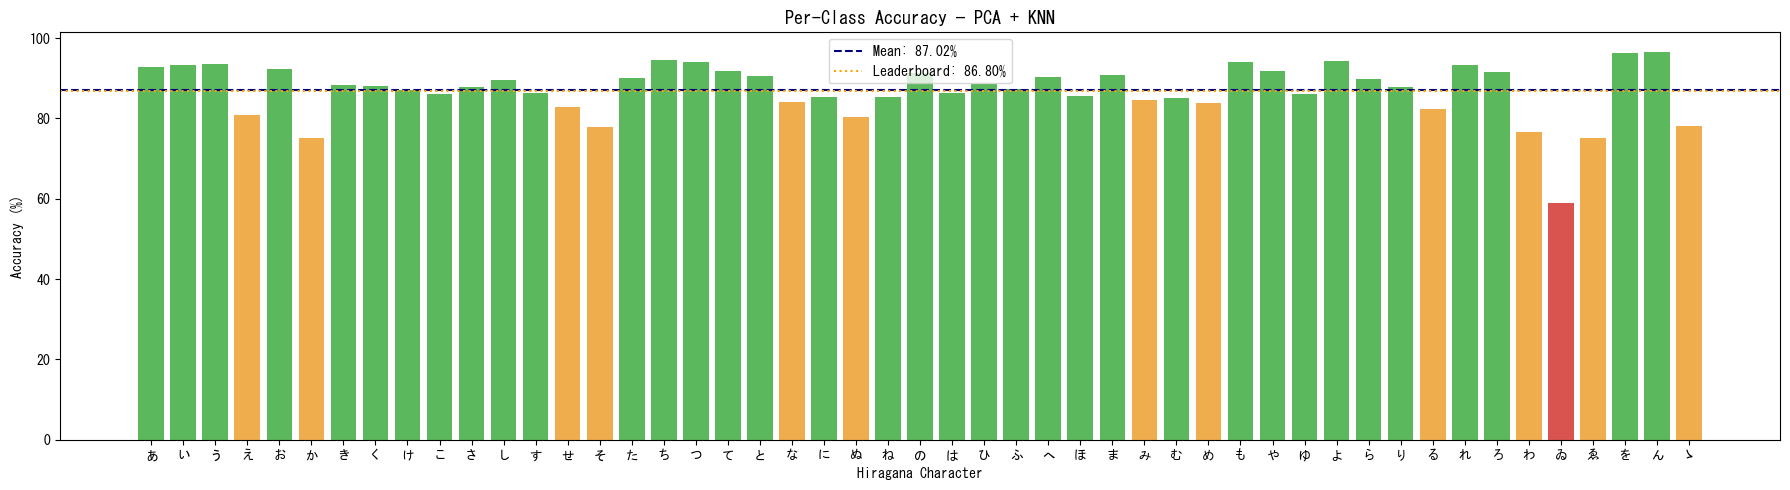

10 Hardest Characters:
    Char    Accuracy
----------------------
       ゐ      58.82%
       ゑ      75.00%
       か      75.20%
       わ      76.67%
       そ      77.90%
       ゝ      78.05%
       ぬ      80.36%
       え      80.95%
       る      82.30%
       せ      82.74%


In [34]:
# Per-class accuracy bar chart
plt.figure(figsize=(18, 5))
colors = ['#d9534f' if a < 0.75 else '#f0ad4e' if a < 0.85 else '#5cb85c'
          for a in per_class_accs]
plt.bar(target_names, [a*100 for a in per_class_accs], color=colors)
plt.axhline(test_acc_classavg*100, color='navy', linestyle='--',
            label=f'Mean: {test_acc_classavg*100:.2f}%')
plt.axhline(86.80, color='orange', linestyle=':', label='Leaderboard: 86.80%')
plt.title('Per-Class Accuracy — PCA + KNN', fontsize=13)
plt.xlabel('Hiragana Character')
plt.ylabel('Accuracy (%)')
plt.xticks(fontsize=9)
plt.legend()
plt.tight_layout()
plt.show()

# Worst performing classes
worst = sorted(enumerate(per_class_accs), key=lambda x: x[1])[:10]
print('10 Hardest Characters:')
print(f'{"Char":>8}  {"Accuracy":>10}')
print('-' * 22)
for idx, acc in worst:
    print(f'{target_names[idx]:>8}  {acc*100:>9.2f}%')

### 9b. Best Performing Classes (IMPROVEMENT)

The original only shows the 10 hardest characters. Knowing the easiest ones
is equally useful — it confirms the model is reliable for certain characters
and helps prioritize which classes need more data or augmentation.


In [35]:
# ── Top 10 easiest characters ────────────────────────────────────────────────
best = sorted(enumerate(per_class_accs), key=lambda x: x[1], reverse=True)[:10]
print('10 Easiest Characters:')
print(f'{"Char":>8}  {"Accuracy":>10}')
print('-' * 22)
for idx, acc in best:
    print(f'{target_names[idx]:>8}  {acc*100:>9.2f}%')


10 Easiest Characters:
    Char    Accuracy
----------------------
       ん      96.60%
       を      96.40%
       ち      94.50%
       よ      94.30%
       つ      94.10%
       も      94.10%
       う      93.50%
       れ      93.40%
       い      93.20%
       あ      92.90%


## 10. Confusion Matrix

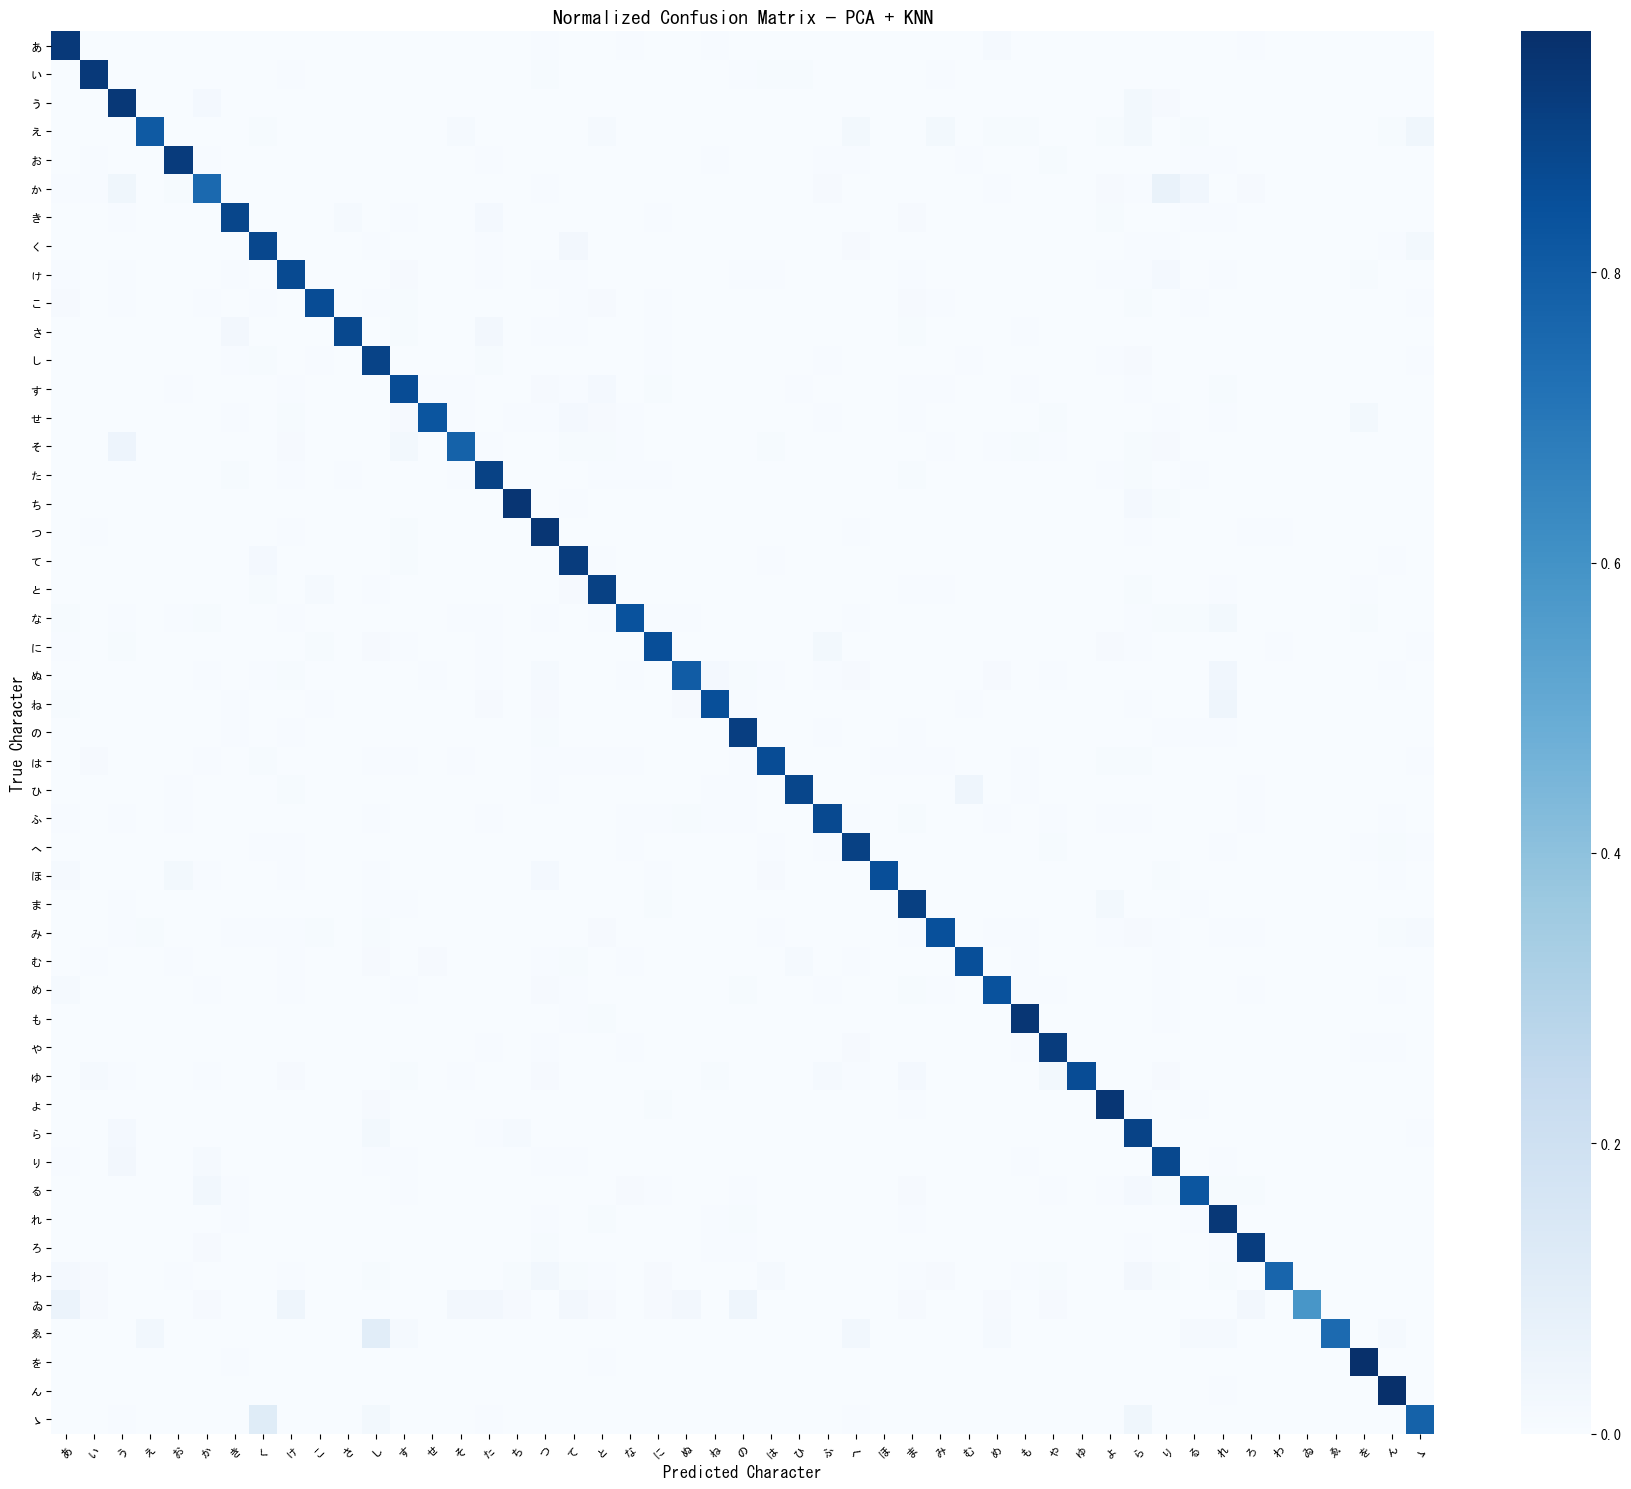

In [36]:
cm      = confusion_matrix(y_test, y_test_pred)
cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)

plt.figure(figsize=(18, 15))
sns.heatmap(cm_norm, annot=False, fmt='.2f', cmap='Blues',
            xticklabels=target_names, yticklabels=target_names)
plt.title('Normalized Confusion Matrix — PCA + KNN', fontsize=14)
plt.xlabel('Predicted Character', fontsize=12)
plt.ylabel('True Character', fontsize=12)
plt.xticks(fontsize=8, rotation=45)
plt.yticks(fontsize=8, rotation=0)
plt.tight_layout()
plt.show()

In [37]:
confused_pairs = [
    (cm_norm[i, j], target_names[i], target_names[j])
    for i in range(len(target_names))
    for j in range(len(target_names))
    if i != j
]
confused_pairs.sort(reverse=True)

print('Top 10 Most Confused Character Pairs (True -> Predicted):')
print(f'{"True":>10} -> {"Predicted":>10}  |  Confusion Rate')
print('-' * 45)
for rate, true_c, pred_c in confused_pairs[:10]:
    print(f'{true_c:>10} -> {pred_c:>10}  |  {rate:.4f} ({rate*100:.2f}%)')

Top 10 Most Confused Character Pairs (True -> Predicted):
      True ->  Predicted  |  Confusion Rate
---------------------------------------------
         ゝ ->          く  |  0.1167 (11.67%)
         ゑ ->          し  |  0.1094 (10.94%)
         か ->          り  |  0.0680 (6.80%)
         ゐ ->          あ  |  0.0588 (5.88%)
         そ ->          う  |  0.0525 (5.25%)
         ひ ->          む  |  0.0467 (4.67%)
         ゐ ->          の  |  0.0441 (4.41%)
         ゐ ->          け  |  0.0441 (4.41%)
         ね ->          れ  |  0.0426 (4.26%)
         か ->          う  |  0.0410 (4.10%)


## 11. Deployment Decision

Based on the speed test in Section 6, we decide which model to deploy.

In [38]:
print('=' * 55)
print('  Deployment Decision')
print('=' * 55)
print(f'  KNN inference time : {test_infer_time:.2f} ms/sample')
print(f'  Constraint         : < 100 ms')
print()
if test_infer_time < 100:
    print('  ✅ KNN meets the constraint.')
    print('  → Deploy PCA + KNN as primary model.')
    print(f'  → Test accuracy: {test_acc_classavg*100:.2f}% (class avg)')
else:
    print('  ❌ KNN is too slow for real-time deployment.')
    print('  → Fall back to Linear SVM v3 (0.007 ms/sample)')
    print('  → Or use Tuned RBF SVM from leaderboard (Section 12)')
print('=' * 55)

  Deployment Decision
  KNN inference time : 1.02 ms/sample
  Constraint         : < 100 ms

  ✅ KNN meets the constraint.
  → Deploy PCA + KNN as primary model.
  → Test accuracy: 87.02% (class avg)


## 12. Fallback — Tuned RBF SVM (if KNN too slow)

If KNN fails the speed constraint, this cell trains the **leaderboard Tuned RBF SVM** using the pre-found parameters C=4.15, gamma=0.00678 on raw pixels — no search needed.

⚠️ Full training on 232,365 samples takes **more than 1 day** on CPU (as noted by the leaderboard author). We use a **100,000-sample stratified subset** as a practical compromise — still significantly more data than our previous RBF attempt (50k).

In [39]:
# Only run this cell if KNN failed the speed test
RUN_FALLBACK_SVM = test_infer_time >= 100   # auto-triggered if KNN is too slow

if RUN_FALLBACK_SVM:
    from sklearn.utils import resample
    import threading
    from tqdm import tqdm

    # Leaderboard pre-tuned parameters — no search needed
    C_rbf     = 4.152705171689228
    gamma_rbf = 0.006783091541660457
    SUBSET    = 100_000

    # Stratified subset of raw pixels (no HOG, no PCA for RBF)
    X_rbf, y_rbf = resample(
        X_train_flat, y_train,
        n_samples=SUBSET, random_state=42, stratify=y_train
    )

    rbf_svm = SVC(
        C=C_rbf, gamma=gamma_rbf,
        kernel='rbf',
        decision_function_shape='ovr',
        probability=False,
        random_state=42
    )

    print(f'⏳ Training Tuned RBF SVM on {SUBSET:,} raw pixel samples...')
    print(f'   C={C_rbf:.4f}, gamma={gamma_rbf:.6f}')

    t0   = time.time()
    done = threading.Event()

    def train_rbf():
        rbf_svm.fit(X_rbf, y_rbf)
        done.set()

    thread = threading.Thread(target=train_rbf)
    thread.start()

    from tqdm import tqdm
    with tqdm(desc='Training RBF SVM', bar_format='{desc} | {elapsed} elapsed') as pbar:
        while not done.is_set():
            pbar.update(0)
            done.wait(timeout=0.5)

    thread.join()
    rbf_train_time = time.time() - t0
    print(f'✅ Done in {rbf_train_time/60:.1f} min')

    # Evaluate RBF SVM
    t0 = time.time()
    y_rbf_pred      = rbf_svm.predict(X_test_flat)
    rbf_infer_time  = (time.time() - t0) / len(y_test) * 1000

    rbf_per_class = []
    for cls in range(49):
        mask = (y_test == cls)
        rbf_per_class.append((y_rbf_pred[mask] == cls).mean())
    rbf_acc_classavg = np.mean(rbf_per_class)
    rbf_f1 = f1_score(y_test, y_rbf_pred, average='macro')

    print('=' * 45)
    print('  Tuned RBF SVM Results (Fallback)')
    print('=' * 45)
    print(f'  Mean Per-Class Accuracy : {rbf_acc_classavg*100:.2f}%')
    print(f'  Macro F1-Score          : {rbf_f1:.4f}')
    print(f'  Inference time/sample   : {rbf_infer_time:.2f} ms')
    print(f'  Real-time ready         : {"✅ YES" if rbf_infer_time < 100 else "❌ NO"}')
    print('=' * 45)

    os.makedirs('../models', exist_ok=True)
    joblib.dump(rbf_svm, '../models/tuned_rbf_svm.pkl')
    print('✅ Tuned RBF SVM saved.')

else:
    print('KNN met the speed constraint — fallback SVM not needed.')

KNN met the speed constraint — fallback SVM not needed.


## 13. Save KNN Model

In [40]:
os.makedirs('../models', exist_ok=True)

joblib.dump(clf, '../models/pca_knn.pkl')
joblib.dump(pca, '../models/pca_knn_pca.pkl')

print('✅ Models saved:')
print('   ../models/pca_knn.pkl      — KNN classifier')
print('   ../models/pca_knn_pca.pkl  — PCA transformer')
print()
print('Inference pipeline for deployment:')
print('   raw_pixels → /255 → flatten → pca.transform → clf.predict')

✅ Models saved:
   ../models/pca_knn.pkl      — KNN classifier
   ../models/pca_knn_pca.pkl  — PCA transformer

Inference pipeline for deployment:
   raw_pixels → /255 → flatten → pca.transform → clf.predict


### 13b.  Save as Bundled Pipeline (IMPROVEMENT)

The original saves PCA and KNN as **two separate files** — risky in Flask because
loading them in the wrong order or forgetting one causes silent errors.

A scikit-learn `Pipeline` bundles both into one file. In Flask: one load, one call.


In [41]:
from sklearn.pipeline import Pipeline

# ── Bundle PCA + KNN into one serializable object ────────────────────────────
pipeline = Pipeline([
    ('pca', pca),
    ('knn', clf)
])

joblib.dump(pipeline, '../models/pca_knn_pipeline.joblib')
size_mb = os.path.getsize('../models/pca_knn_pipeline.joblib') / 1024**2

print(f'✅ Bundled pipeline saved → ../models/pca_knn_pipeline.joblib  ({size_mb:.1f} MB)')
print()
print('Flask usage (replaces loading two files separately):')
print('  pipeline = joblib.load("model/pca_knn_pipeline.joblib")')
print('  x        = raw_pixels.reshape(1, 784).astype("float32") / 255.0')
print('  proba    = pipeline.predict_proba(x)[0]   # PCA + KNN in one call')
print('  top5     = np.argsort(proba)[::-1][:5]')


✅ Bundled pipeline saved → ../models/pca_knn_pipeline.joblib  (55.1 MB)

Flask usage (replaces loading two files separately):
  pipeline = joblib.load("model/pca_knn_pipeline.joblib")
  x        = raw_pixels.reshape(1, 784).astype("float32") / 255.0
  proba    = pipeline.predict_proba(x)[0]   # PCA + KNN in one call
  top5     = np.argsort(proba)[::-1][:5]


### Quick Reload

In [42]:
# Uncomment to reload on subsequent sessions
# clf = joblib.load('../models/pca_knn.pkl')
# pca = joblib.load('../models/pca_knn_pca.pkl')
# X_test_pca = pca.transform(X_test_raw.reshape(-1,784).astype('float32')/255.0)
# print('Reloaded — continue from Section 7.')

---
## Summary

### Key findings

| Finding | Evidence |
|---|---|
| HOG hurts on K49 | Raw pixels (83.65%) beat HOG+SVM (80.07%) even with nearest-neighbour |
| PCA improves KNN | PCA+KNN (86.80%) beats plain KNN (83.65%) by 3.15% |
| 60 components is enough | Leaderboard confirmed — more components adds noise not signal |
| Speed is the deployment risk | KNN trades training speed for prediction cost |

### Deployment recommendation
- **If KNN < 100ms** → Deploy PCA + KNN — highest classical accuracy at 86.80%
- **If KNN ≥ 100ms** → Deploy Tuned RBF SVM on raw pixels — still beats HOG+SVM
- **Either way** → Linear SVM v3 (80.07%) is retired as the primary model